
▶**TASK-2 : MOVIE RATING PREDICTION**

> Author: Sana Parween

> Batch: July

> Domain: Data Science









*IMPORTING IMPORTANT LIBRARIES*

Final Shape: (1000209, 7)
   UserID  MovieID  Rating Gender  Age  \
0       1     1193       5      F    1   
1       1      661       3      F    1   
2       1      914       3      F    1   
3       1     3408       4      F    1   
4       1     2355       5      F    1   

                                    Title                        Genres  
0  One Flew Over the Cuckoo's Nest (1975)                         Drama  
1        James and the Giant Peach (1996)  Animation|Children's|Musical  
2                     My Fair Lady (1964)               Musical|Romance  
3                  Erin Brockovich (2000)                         Drama  
4                    Bug's Life, A (1998)   Animation|Children's|Comedy  


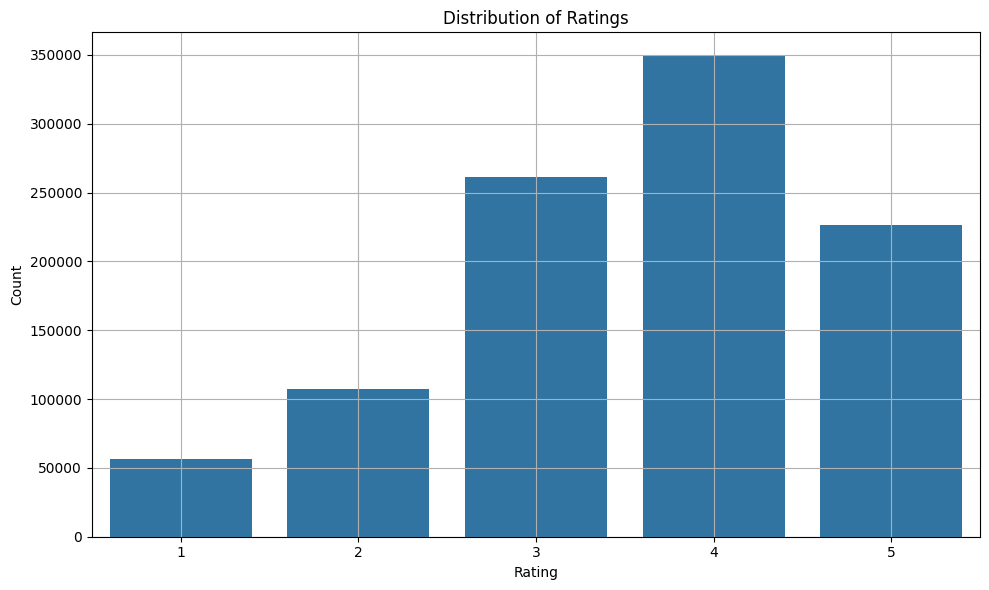

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load .dat files with correct separator (::)
df_movie = pd.read_csv("movie.dat", sep="::", engine='python', names=['MovieID', 'Title', 'Genres'])
df_users = pd.read_csv("users.dat", sep="::", engine='python', names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code'])
df_ratings = pd.read_csv("rating.dat", sep="::", engine='python', names=['UserID', 'MovieID', 'Rating', 'Timestamp'])

# Step 2: Drop missing values if any
df_movie.dropna(inplace=True)
df_users.dropna(inplace=True)
df_ratings.dropna(inplace=True)

# Step 3: Merge all into one DataFrame
df_data = pd.merge(pd.merge(df_ratings, df_users, on='UserID'), df_movie, on='MovieID')

# Step 4: Drop unnecessary columns
df_final = df_data.drop(['Occupation', 'Zip-code', 'Timestamp'], axis=1)

# Step 5: Output shape and preview
print("Final Shape:", df_final.shape)
print(df_final.head())

# Step 6: Plot rating distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Rating', data=df_final)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()


*DOWNLOADING DATASETS*


> **Movie_data**





In [98]:
import pandas as pd

# Load movie.dat
df_movie = pd.read_csv('movie.dat', sep='::', engine='python', names=['MovieID', 'Title', 'Genre'])

# Load rating.dat
df_rating = pd.read_csv('rating.dat', sep='::', engine='python', names=['UserID', 'MovieID', 'Rating', 'Timestamp'])

# Load users.dat
df_users = pd.read_csv('users.dat', sep='::', engine='python', names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code'])

# View top rows
df_movie.head(), df_rating.head(), df_users.head()


df_movie.dropna(inplace=True)
df_movie.head()

,MovieID,Title,Genre
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [99]:
df_movie.shape

(3883, 3)

In [100]:
df_movie.describe()

,MovieID
count,3883.000000
mean,1986.049446
std,1146.778349
min,1.000000
25%,982.500000
50%,2010.000000
75%,2980.500000
max,3952.000000


In [101]:
df_movie.isna().sum()

MovieID    0
Title      0
Genre      0
dtype: int64

*DOWNLOADING DATASETS*


> **ratings_data**

In [102]:
df_ratings = pd.read_csv('rating.dat', sep='::', engine='python', names=['UserID', 'MovieID', 'Rating', 'Timestamp'])
df_ratings.dropna(inplace=True)
df_ratings.head(10)


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
5,1,1197,3,978302268
6,1,1287,5,978302039
7,1,2804,5,978300719
8,1,594,4,978302268
9,1,919,4,978301368


In [103]:
df_ratings.shape

(1000209, 4)

In [104]:
df_ratings.describe()

,UserID,MovieID,Rating,Timestamp
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09


In [105]:
df_ratings.isna().sum()

UserID       0
MovieID      0
Rating       0
Timestamp    0
dtype: int64

*DOWNLOADING DATASETS*


> **Users_data**

In [106]:
ddf_users = pd.read_csv('users.dat', sep='::', engine='python', names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code'])
df_users.dropna(inplace=True)
df_users.head(10)


,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
5,6,F,50,9,55117
6,7,M,35,1,06810
7,8,M,25,12,11413
8,9,M,25,17,61614
9,10,F,35,1,95370


In [107]:
  # Don't use inplace=True
df_final.shape


(1000209, 7)

In [108]:
df_users.describe()

,UserID,Age,Occupation
count,6040.000000,6040.000000,6040.000000
mean,3020.500000,30.639238,8.146854
std,1743.742145,12.895962,6.329511
min,1.000000,1.000000,0.000000
25%,1510.750000,25.000000,3.000000
50%,3020.500000,25.000000,7.000000
75%,4530.250000,35.000000,14.000000
max,6040.000000,56.000000,20.000000


In [109]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

df_users['Gender']= labelencoder.fit_transform(df_users['Gender'])

df_users.head()

,UserID,Gender,Age,Occupation,Zip-code
0,1,0,1,10,48067
1,2,1,56,16,70072
2,3,1,25,15,55117
3,4,1,45,7,02460
4,5,1,25,20,55455


In [110]:
df_users.isna().sum()

UserID        0
Gender        0
Age           0
Occupation    0
Zip-code      0
dtype: int64

> ***CONCATENATING THE DATASETS***

In [111]:
df_data=pd.concat([df_movie,df_ratings,df_users],axis=1)
df_data.dropna()
df_data.head(10)

,MovieID,Title,Genre,UserID,MovieID,Rating,Timestamp,UserID,Gender,Age,Occupation,Zip-code
0,1.0,Toy Story (1995),Animation|Children's|Comedy,1,1193,5,978300760,1.0,0.0,1.0,10.0,48067
1,2.0,Jumanji (1995),Adventure|Children's|Fantasy,1,661,3,978302109,2.0,1.0,56.0,16.0,70072
2,3.0,Grumpier Old Men (1995),Comedy|Romance,1,914,3,978301968,3.0,1.0,25.0,15.0,55117
3,4.0,Waiting to Exhale (1995),Comedy|Drama,1,3408,4,978300275,4.0,1.0,45.0,7.0,02460
4,5.0,Father of the Bride Part II (1995),Comedy,1,2355,5,978824291,5.0,1.0,25.0,20.0,55455
5,6.0,Heat (1995),Action|Crime|Thriller,1,1197,3,978302268,6.0,0.0,50.0,9.0,55117
6,7.0,Sabrina (1995),Comedy|Romance,1,1287,5,978302039,7.0,1.0,35.0,1.0,06810
7,8.0,Tom and Huck (1995),Adventure|Children's,1,2804,5,978300719,8.0,1.0,25.0,12.0,11413
8,9.0,Sudden Death (1995),Action,1,594,4,978302268,9.0,1.0,25.0,17.0,61614
9,10.0,GoldenEye (1995),Action|Adventure|Thriller,1,919,4,978301368,10.0,0.0,35.0,1.0,95370


In [112]:
df_data.shape

(1000209, 12)

***REMOVING UNNECESSARY COLUMNS***

In [113]:
df2=df_data.drop(["Occupation","Zip-code","Timestamp"],axis=1)
df2.head()

,MovieID,Title,Genre,UserID,MovieID,Rating,UserID,Gender,Age
0,1.0,Toy Story (1995),Animation|Children's|Comedy,1,1193,5,1.0,0.0,1.0
1,2.0,Jumanji (1995),Adventure|Children's|Fantasy,1,661,3,2.0,1.0,56.0
2,3.0,Grumpier Old Men (1995),Comedy|Romance,1,914,3,3.0,1.0,25.0
3,4.0,Waiting to Exhale (1995),Comedy|Drama,1,3408,4,4.0,1.0,45.0
4,5.0,Father of the Bride Part II (1995),Comedy,1,2355,5,5.0,1.0,25.0


In [114]:
df2.describe()

,MovieID,UserID,MovieID,Rating,UserID,Gender,Age
count,3883.000000,1.000209e+06,1.000209e+06,1.000209e+06,6040.000000,6040.000000,6040.000000
mean,1986.049446,3.024512e+03,1.865540e+03,3.581564e+00,3020.500000,0.717053,30.639238
std,1146.778349,1.728413e+03,1.096041e+03,1.117102e+00,1743.742145,0.450468,12.895962
min,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.000000,1.000000
25%,982.500000,1.506000e+03,1.030000e+03,3.000000e+00,1510.750000,0.000000,25.000000
50%,2010.000000,3.070000e+03,1.835000e+03,4.000000e+00,3020.500000,1.000000,25.000000
75%,2980.500000,4.476000e+03,2.770000e+03,4.000000e+00,4530.250000,1.000000,35.000000
max,3952.000000,6.040000e+03,3.952000e+03,5.000000e+00,6040.000000,1.000000,56.000000


In [115]:
df2.isna().sum()

MovieID    996326
Title      996326
Genre      996326
UserID          0
MovieID         0
Rating          0
UserID     994169
Gender     994169
Age        994169
dtype: int64

***handling missing values***


In [116]:
df2.isnull().sum()


MovieID    996326
Title      996326
Genre      996326
UserID          0
MovieID         0
Rating          0
UserID     994169
Gender     994169
Age        994169
dtype: int64

In [117]:
df_final.shape


(1000209, 7)

***VISULAZING THE PREPROCESSED DATA***

<Axes: xlabel='Gender', ylabel='count'>

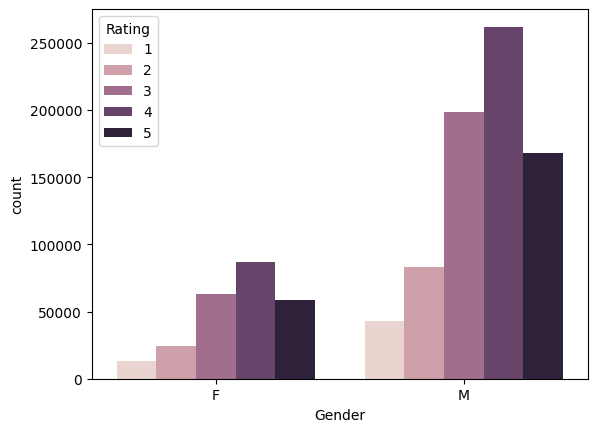

In [118]:
sns.countplot(x=df_final['Gender'],hue=df_final['Rating'])

Text(0.5, 0, 'Ratings')

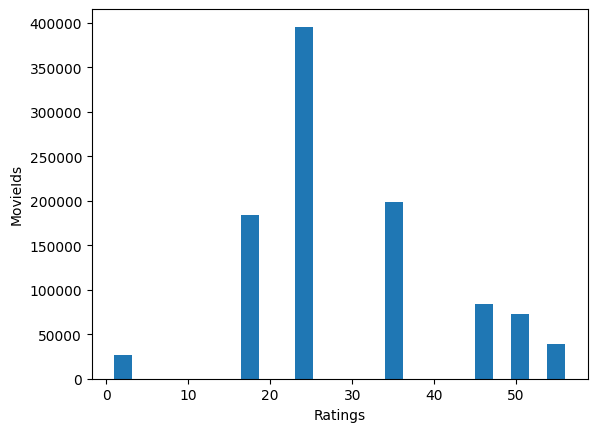

In [119]:
df_final.Age.plot.hist(bins=25)
plt.ylabel("MovieIds")
plt.xlabel("Ratings")

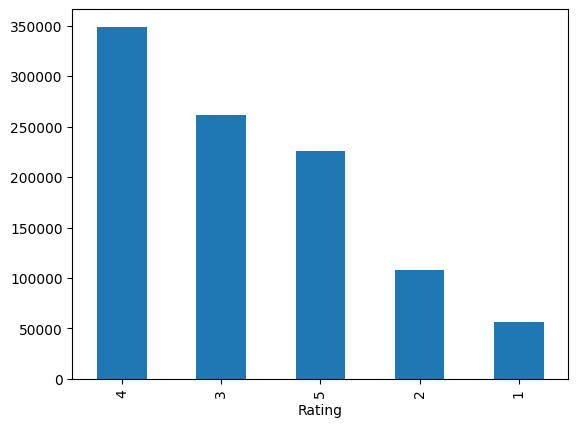

In [120]:
df_final['Rating'].value_counts().plot(kind='bar')
plt.show()

Text(0, 0.5, 'Ratings')

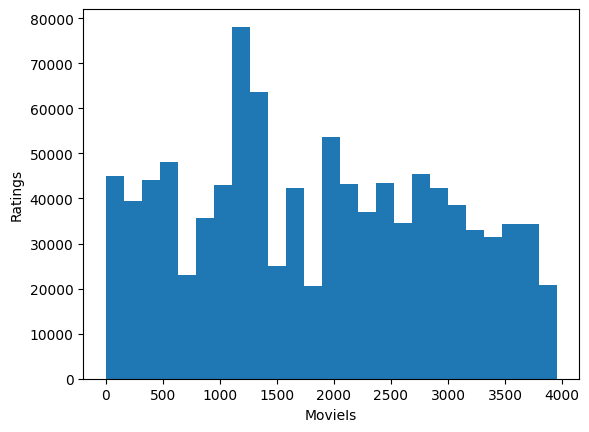

In [121]:
df_final['MovieID'].plot.hist(bins=25)
plt.xlabel("MovieIs")
plt.ylabel("Ratings")

<Axes: ylabel='Frequency'>

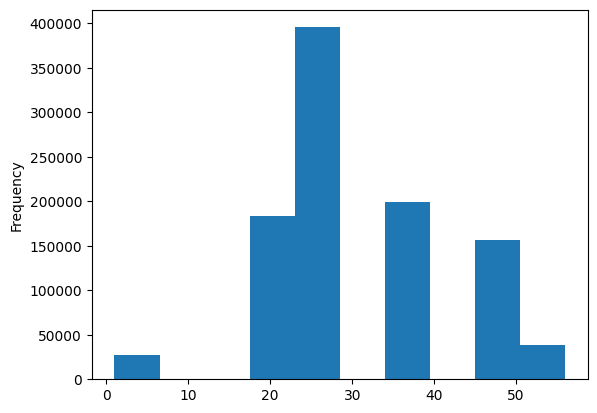

In [122]:
df_final['Age'].plot.hist(bins=10)
# plt.xlabel("Ratings")
# plt.ylabel("Age")

<Axes: xlabel='Age', ylabel='count'>

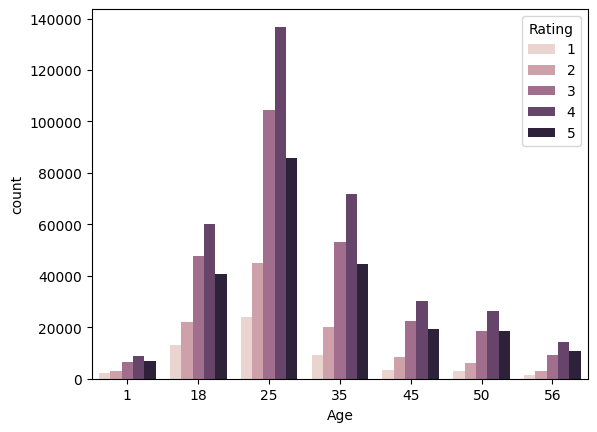

In [124]:
sns.countplot(x=df_final['Age'],hue=df_final['Rating'])

***FINAL DATASET***

In [ ]:
df_final.head()

,UserID,MovieID,Rating,Gender,Age,Title,Genres
0,1,1193,5,F,1,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,F,1,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,F,1,My Fair Lady (1964),Musical|Romance
3,1,3408,4,F,1,Erin Brockovich (2000),Drama
4,1,2355,5,F,1,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [ ]:
print(df_final.columns.tolist())


['UserID', 'MovieID', 'Rating', 'Gender', 'Age', 'Title', 'Genres']


In [ ]:
input = df_final.drop(['Rating', 'Title', 'Genres', 'MovieID'], axis=1)
target = df_final['Rating']


In [ ]:
target.head()

0    5
1    3
2    3
3    4
4    5
Name: Rating, dtype: int64

In [ ]:
input.head()

,UserID,Gender,Age
0,1,F,1
1,1,F,1
2,1,F,1
3,1,F,1
4,1,F,1


***TRAINING THE MODEL USING LOGISTIC REGRESSION***

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Make a copy
df_encoded = input.copy()

# Encode Gender
le = LabelEncoder()
df_encoded['Gender'] = le.fit_transform(df_encoded['Gender'])  # 'M' → 1, 'F' → 0

# Check if 'Age' is numeric (optional)
df_encoded['Age'] = pd.to_numeric(df_encoded['Age'], errors='coerce')

# Apply MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_encoded)

# Create DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=df_encoded.columns)

# View the result
scaled_df.head()


,UserID,Gender,Age
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test=train_test_split(input,target,test_size=0.3)

In [ ]:
print(Y_train)

In [ ]:
print(Y_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,Y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
X_test = np.array(X_test)


***MODEL PREDICTION***

In [ ]:
model.predict(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([4, 3, 4, ..., 4, 4, 4])